In [1]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
from probeinterface import write_probeinterface, read_probeinterface, Probe
from scipy.io import loadmat
import pickle

probe_data = loadmat("/media/ubuntu/sda/duan/raw_data/chanMap_DCX_5mm.mat")
probe_x = probe_data['xcoords']
probe_y = probe_data['ycoords']

probe_position = pd.DataFrame(probe_x)
probe_position[1] = probe_y
probe_position['chan_map'] = probe_data['chanMap0ind'].astype(int)

chan_map = pd.read_csv('/media/ubuntu/sda/duan/raw_data/ch_map_R.csv')
merged = chan_map.merge(probe_position, left_on='probeloc', right_on='chan_map')\
                 .iloc[chan_map.index]\
                 .reset_index(drop=True)

probe = Probe()
probe.set_contacts(positions=merged.iloc[:, 2:4])
probe.set_device_channel_indices(range(256))


In [ ]:
recording_raw = se.read_intan(f"/home/ubuntu/Documents/jct/project/251205/M190011_251205_125223_merged_130.rhd", stream_id= '0', ignore_integrity_checks=True)

print('read success')

recording_raw = spre.unsigned_to_signed(recording_raw)
recording_raw = spre.resample(recording_raw, 10000)

recording_recorded = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_recorded, freq=50)
recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

recording_f = recording_f.set_probegroup(probe)

#rec_corrected, motion = spre.correct_motion(recording=recording_f, preset="dredge_fast", output_motion=True, n_jobs = 30)
#recording_preprocessed = recording_f.save(format="binary", n_jobs = 30)


In [ ]:
import spikeinterface as si
import numpy as np
from spikeinterface.core import get_template_extremum_channel
import scipy.spatial.distance
from scipy.sparse.csgraph import connected_components
import pickle
import pandas as pd

output_dir = '/home/ubuntu/Documents/jct/project/sorted/251205_kilosort'
sorting_curated_phy = se.read_phy(f"{output_dir}/phy_folder_for_kilosort", exclude_cluster_groups=["noise"])
analyzer_curated_phy = si.create_sorting_analyzer(
    sorting=sorting_curated_phy, 
    recording=recording_f, 
    format='binary_folder',
    folder=output_dir + '/analyzer_curated',
    n_jobs=20
)

extensions_to_compute = [
    "random_spikes",
    "waveforms",
    "noise_levels",
    "templates",
    "unit_locations",
    "spike_locations",
    "correlograms",
    "template_similarity"
]

extension_params = {
    "random_spikes": {"method": "all"},
    "unit_locations": {"method": "center_of_mass"},
    "spike_locations": {"ms_before": 0.1},
    "correlograms": {"bin_ms": 0.1},
    "template_similarity": {"method": "cosine_similarity"}
}

analyzer_curated_phy.compute(extensions_to_compute, extension_params=extension_params, n_jobs=25)

templates_ext = analyzer_curated_phy.get_extension("templates")
templates_dense = templates_ext.data["average"]
sparsity = analyzer_curated_phy.sparsity
unit_locations_ext = analyzer_curated_phy.get_extension("unit_locations")
unit_locations = unit_locations_ext.get_data()
channel_locations = analyzer_curated_phy.get_channel_locations()

if unit_locations.shape[1] >= 2:
    unit_distances = scipy.spatial.distance.cdist(
        unit_locations[:, :2], 
        unit_locations[:, :2], 
        metric="euclidean"
    )
else:
    unit_distances = scipy.spatial.distance.cdist(
        unit_locations, 
        unit_locations, 
        metric="euclidean"
    )

template_similarity_ext = analyzer_curated_phy.get_extension("template_similarity")
template_similarity = template_similarity_ext.get_data()

distance_threshold = 10.0
similarity_threshold = 0.95
num_units = len(analyzer_curated_phy.unit_ids)
pair_mask = np.zeros((num_units, num_units), dtype=bool)

for i in range(num_units):
    for j in range(i + 1, num_units):
        if unit_distances[i, j] < distance_threshold and template_similarity[i, j] > similarity_threshold:
            pair_mask[i, j] = True
            pair_mask[j, i] = True

n_components, labels = connected_components(
    csgraph=pair_mask, 
    directed=False, 
    return_labels=True
)

merge_unit_groups = []
unit_ids_list = analyzer_curated_phy.unit_ids
for component_id in range(n_components):
    unit_indices = np.where(labels == component_id)[0]
    if len(unit_indices) > 1:
        group = [unit_ids_list[i] for i in unit_indices]
        merge_unit_groups.append(group)

if len(merge_unit_groups) > 0:
    analyzer_merged = analyzer_curated_phy.merge_units(
        merge_unit_groups=merge_unit_groups,
        censor_ms=0.3,
        merging_mode="hard",
        new_id_strategy="append",
        format='binary_folder',
        folder=output_dir + '/analyzer_merged',
        verbose=True,
        n_jobs=20
    )
    
    analyzer_merged.compute(extensions_to_compute, extension_params=extension_params, n_jobs=30)
    
    templates_ext_merged = analyzer_merged.get_extension("templates")
    templates_dense_merged = templates_ext_merged.data["average"]
    sparsity_merged = analyzer_merged.sparsity
    unit_locations_ext_merged = analyzer_merged.get_extension("unit_locations")
    unit_locations_merged = unit_locations_ext_merged.get_data()
    channel_locations_merged = analyzer_merged.get_channel_locations()
    
    position_waveforms_merged = []
    unit_ids_list_merged = analyzer_merged.unit_ids
    
    for unit_id in unit_ids_list_merged:
        unit_index = analyzer_merged.sorting.id_to_index(unit_id)
        template_dense_unit = templates_dense_merged[unit_index, :, :]
        template_sparse_unit = sparsity_merged.sparsify_waveforms(template_dense_unit[np.newaxis, :, :], unit_id)[0]
        sparse_channel_indices = sparsity_merged.unit_id_to_channel_indices[unit_id]
        
        if len(sparse_channel_indices) == 0:
            position_waveform = np.zeros(templates_dense_merged.shape[1], dtype=templates_dense_merged.dtype)
            position_waveforms_merged.append(position_waveform)
            continue
        
        sparse_channel_locations = channel_locations_merged[sparse_channel_indices, :2]
        unit_location = unit_locations_merged[unit_index, :2]
        
        distances = np.sqrt(np.sum((sparse_channel_locations - unit_location[np.newaxis, :])**2, axis=1))
        epsilon = 1e-10
        weights = 1.0 / (distances + epsilon)
        weights = weights / np.sum(weights)
        
        position_waveform = np.dot(template_sparse_unit, weights)
        position_waveforms_merged.append(position_waveform)
    
    position_waveforms_merged = np.array(position_waveforms_merged)
    
    extremum_channels_merged = get_template_extremum_channel(
        analyzer_merged, 
        peak_sign="both",
        outputs="id"
    )
    
    neuron_inf = {}
    for idx, unit_id in enumerate(unit_ids_list_merged):
        neuron_inf[unit_id] = {
            'location_x': float(unit_locations_merged[idx, 0]),
            'location_y': float(unit_locations_merged[idx, 1]),
            'position_waveform': position_waveforms_merged[idx],
            'extremum_channel': extremum_channels_merged[unit_id]
        }
    
    sorting_final = analyzer_merged.sorting
    extremum_channels_final = extremum_channels_merged
else:
    position_waveforms = []
    for unit_id in unit_ids_list:
        unit_index = analyzer_curated_phy.sorting.id_to_index(unit_id)
        template_dense_unit = templates_dense[unit_index, :, :]
        template_sparse_unit = sparsity.sparsify_waveforms(template_dense_unit[np.newaxis, :, :], unit_id)[0]
        sparse_channel_indices = sparsity.unit_id_to_channel_indices[unit_id]
        
        if len(sparse_channel_indices) == 0:
            position_waveform = np.zeros(templates_dense.shape[1], dtype=templates_dense.dtype)
            position_waveforms.append(position_waveform)
            continue
        
        sparse_channel_locations = channel_locations[sparse_channel_indices, :2]
        unit_location = unit_locations[unit_index, :2]
        
        distances = np.sqrt(np.sum((sparse_channel_locations - unit_location[np.newaxis, :])**2, axis=1))
        epsilon = 1e-10
        weights = 1.0 / (distances + epsilon)
        weights = weights / np.sum(weights)
        
        position_waveform = np.dot(template_sparse_unit, weights)
        position_waveforms.append(position_waveform)
    
    position_waveforms = np.array(position_waveforms)
    
    extremum_channels = get_template_extremum_channel(
        analyzer_curated_phy, 
        peak_sign="neg",
        outputs="id"
    )
    
    neuron_inf = {}
    for idx, unit_id in enumerate(unit_ids_list):
        neuron_inf[unit_id] = {
            'location_x': float(unit_locations[idx, 0]),
            'location_y': float(unit_locations[idx, 1]),
            'position_waveform': position_waveforms[idx],
            'extremum_channel': extremum_channels[unit_id]
        }
    
    sorting_final = analyzer_curated_phy.sorting
    extremum_channels_final = extremum_channels

spike_vector = sorting_final.to_spike_vector()

gt_detect_data = []
for spike in spike_vector:
    unit_index = spike['unit_index']
    unit_id = sorting_final.unit_ids[unit_index]
    sample_index = spike['sample_index']
    
    extremum_channel = extremum_channels_final[unit_id]
    
    gt_detect_data.append({
        'sample_index': sample_index,
        'unit_id': unit_id,
        'extremum_channel': str(extremum_channel)
    })

gt_detect_array = pd.DataFrame(gt_detect_data)

with open(output_dir + '/neuron_inf.pickle', 'wb') as f:
    pickle.dump(neuron_inf, f)

gt_detect_array.to_csv(output_dir + '/gt_detect_array.csv', index=False)

print(f"neuron_inf已保存到: {output_dir + '/neuron_inf.pickle'}")
print(f"包含 {len(neuron_inf)} 个neurons")
print(f"gt_detect_array已保存到: {output_dir + '/gt_detect_array.csv'}")
print(f"包含 {len(gt_detect_array)} 个spikes")
print(f"gt_detect_array列: {gt_detect_array.columns.tolist()}")

In [2]:
output_dir = '/home/ubuntu/Documents/jct/project/sorted/251205_kilosort'
rec_params = pd.read_csv("/home/ubuntu/Documents/jct/project/sorted/251205_kilosort/rec_params.csv")
rec_params = rec_params[rec_params['bhv_codes'] == 10]
rec_params['trial_condition'] = rec_params['trial_condition'].astype(int)
rec_params = rec_params.reset_index()
stimuli_pattern = pd.read_csv('/media/ubuntu/sda/visual_stimuli_pattern/things/visual_stimuli_sequence.csv').iloc[:11427, :]
rec_params = pd.concat((rec_params, stimuli_pattern), axis = 1)
rec_params['rec_codes_points'] = rec_params['rec_codes_points'] / 3 
rec_params['rec_codes_points'] = rec_params['rec_codes_points'].astype(int)
rec_params['end_points'] = rec_params['rec_codes_points'] + 3000
rec_params = rec_params[rec_params['trial_error'] == 0.0]
rec_params = rec_params.reset_index(drop=True)

# 加载neuron数据和spike数据
neuron_inf_path = os.path.join(output_dir, "neuron_inf.pickle")
gt_detect_path = os.path.join(output_dir, "gt_detect_array.csv")

print(f"读取neuron_inf: {neuron_inf_path}")
with open(neuron_inf_path, 'rb') as f:
    neuron_inf = pickle.load(f)

print(f"读取gt_detect_array: {gt_detect_path}")
gt_detect_array = pd.read_csv(gt_detect_path)
gt_detect_array['sample_index'] = pd.to_numeric(gt_detect_array['sample_index'], errors='coerce')
gt_detect_array['unit_id'] = pd.to_numeric(gt_detect_array['unit_id'], errors='coerce')
gt_detect_array = gt_detect_array.dropna(subset=['sample_index', 'unit_id'])

读取neuron_inf: /home/ubuntu/Documents/jct/project/sorted/251205_kilosort/neuron_inf.pickle
读取gt_detect_array: /home/ubuntu/Documents/jct/project/sorted/251205_kilosort/gt_detect_array.csv


In [26]:
with PdfPages(f"{output_dir}/unit_histplots.pdf") as pdf:
    for unit in gt_detect_array['unit_id'].unique():
        sample_max = gt_detect_array['sample_index'].max()
        temp = gt_detect_array[gt_detect_array['unit_id'] == unit]
        plt.figure(figsize=(6, 4))
        sns.histplot(temp['sample_index'])
        plt.xlim(0, sample_max)
        plt.title(unit)
        plt.xlabel('Sample Index')
        pdf.savefig()
        plt.close()



In [3]:
# 1. Unit筛选：基于采样点bin的spike数量统计
import numpy as np

# 获取总采样点范围
sample_min = gt_detect_array['sample_index'].min()
sample_max = gt_detect_array['sample_index'].max()
total_samples = sample_max - sample_min

# 创建5个等分的采样点bin边界
n_bins = 5
bin_edges = np.linspace(sample_min, sample_max, n_bins + 1)

# 为每个spike分配bin标签
gt_detect_array['sample_bin'] = pd.cut(gt_detect_array['sample_index'], bins=bin_edges, labels=range(n_bins), include_lowest=True)

# 获取所有唯一的unit_id
all_unit_ids = sorted(gt_detect_array['unit_id'].unique())
n_units = len(all_unit_ids)

# 创建(n_unit, 5)的矩阵，统计每个unit在每个bin中的spike数量
spike_count_matrix = np.zeros((n_units, n_bins), dtype=int)

for i, unit_id in enumerate(all_unit_ids):
    unit_data = gt_detect_array[gt_detect_array['unit_id'] == unit_id]
    for bin_idx in range(n_bins):
        spike_count_matrix[i, bin_idx] = len(unit_data[unit_data['sample_bin'] == bin_idx])

print(f"Spike count matrix shape: {spike_count_matrix.shape}")
print(f"Total units: {n_units}")

# 进行筛选：对于每个unit，检查是否满足条件
valid_units = []
invalid_units = []

for i, unit_id in enumerate(all_unit_ids):
    spike_counts = spike_count_matrix[i, :]
    
    # 找到最大的前两个bin
    top2_indices = np.argsort(spike_counts)[-2:]
    top2_values = spike_counts[top2_indices]
    
    # 计算这两个bin的平均值
    top2_mean = np.mean(top2_values)
    
    # 获取剩下的三个bin
    remaining_indices = np.setdiff1d(range(n_bins), top2_indices)
    remaining_values = spike_counts[remaining_indices]
    
    # 检查剩下的三个bin中是否有任意一个小于平均值的0.1倍
    threshold = top2_mean * 0.1
    if np.any(remaining_values < threshold):
        invalid_units.append(unit_id)
    else:
        valid_units.append(unit_id)

print(f"\n筛选结果:")
print(f"有效units数量: {len(valid_units)}")
print(f"无效units数量: {len(invalid_units)}")
print(f"\n有效units: {valid_units}")
print(f"\n无效units: {invalid_units}")

# 保存筛选结果
valid_units_array = np.array(valid_units)
invalid_units_array = np.array(invalid_units)

# 保存到文件
np.save(f"{output_dir}/valid_units.npy", valid_units_array)
np.save(f"{output_dir}/invalid_units.npy", invalid_units_array)
np.save(f"{output_dir}/spike_count_matrix.npy", spike_count_matrix)

print(f"\n筛选结果已保存:")
print(f"  - {output_dir}/valid_units.npy")
print(f"  - {output_dir}/invalid_units.npy")
print(f"  - {output_dir}/spike_count_matrix.npy")


Spike count matrix shape: (104, 5)
Total units: 104

筛选结果:
有效units数量: 48
无效units数量: 56

有效units: [np.int64(75), np.int64(79), np.int64(88), np.int64(89), np.int64(94), np.int64(100), np.int64(113), np.int64(117), np.int64(118), np.int64(119), np.int64(121), np.int64(125), np.int64(126), np.int64(128), np.int64(131), np.int64(141), np.int64(142), np.int64(150), np.int64(154), np.int64(158), np.int64(159), np.int64(160), np.int64(161), np.int64(162), np.int64(165), np.int64(222), np.int64(226), np.int64(233), np.int64(235), np.int64(244), np.int64(245), np.int64(247), np.int64(256), np.int64(448), np.int64(449), np.int64(460), np.int64(538), np.int64(540), np.int64(541), np.int64(547), np.int64(549), np.int64(565), np.int64(569), np.int64(572), np.int64(573), np.int64(575), np.int64(577), np.int64(579)]

无效units: [np.int64(25), np.int64(67), np.int64(71), np.int64(73), np.int64(74), np.int64(83), np.int64(91), np.int64(97), np.int64(98), np.int64(105), np.int64(106), np.int64(108), np.in

In [4]:
# 加载rec_params和spike_data（使用Cell 5筛选出的有效units）
# 注意：valid_units_array已经在Cell 5中生成，直接使用内存中的数据
valid_units = valid_units_array
print(f"有效units数量: {len(valid_units)}")

# 筛选只保留有效的units
valid_neuron_inf = {unit_id: neuron_inf[unit_id] for unit_id in valid_units if unit_id in neuron_inf}

# 为每个neuron提取spike times（保持为采样点）
spike_data = {}
for neuron_id in valid_units:
    neuron_spikes = gt_detect_array[gt_detect_array['unit_id'] == neuron_id]['sample_index'].values
    if len(neuron_spikes) > 0:
        spike_data[neuron_id] = neuron_spikes

neuron_inf = valid_neuron_inf

all_trials = rec_params.copy().reset_index(drop=True)


有效units数量: 48


In [5]:
# 2. 计算每个trial每一个有效neuron的PETH（使用histogram方法，用于筛选，不减去baseline）
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d


# 获取所有neuron IDs
all_neuron_ids = sorted(spike_data.keys())
n_neurons = len(all_neuron_ids)
n_trials = len(all_trials)

# 确定标准时间窗口（所有trial应该有相同的长度）
trial_duration_samples = 6000  # 标准trial长度（采样点）
trial_duration_ms = trial_duration_samples * 0.1  # 转换为毫秒 = 400ms

# 设置时间bins（参考single_neuron.ipynb的方法，使用100个bins）
n_time_bins = 100
time_bins = np.linspace(0, trial_duration_ms, n_time_bins)
bin_width_ms = time_bins[1] - time_bins[0]  # bin宽度（毫秒）


# 初始化结果矩阵
# 1. 每个trial的反应: (n_trial, n_neuron, n_time_bins)
trial_peth_matrix = np.zeros((n_trials, n_neurons, n_time_bins - 1))

# 2. 每个neuron的平均反应: (n_neuron, n_time_bins)
neuron_mean_peth_matrix = np.zeros((n_neurons, n_time_bins - 1))

# 遍历每个neuron
for neuron_idx, neuron_id in enumerate(all_neuron_ids):
    if neuron_idx % 10 == 0:
        print(f"  处理neuron {neuron_idx+1}/{n_neurons} (ID: {neuron_id})")
    
    neuron_spikes = spike_data[neuron_id]
    
    # 收集所有trial的spike rates
    trial_spike_rates = []  # 存储每个trial的spike rate数组
    
    # 遍历所有trials
    for trial_idx, (_, trial) in enumerate(all_trials.iterrows()):
        start_ext = int(trial['rec_codes_points']) - 1500
        end_ext = int(trial['end_points']) + 1500
        
        # 获取该trial内的spikes
        trial_spikes = neuron_spikes[(neuron_spikes >= start_ext) & (neuron_spikes <= end_ext)]
        
        if len(trial_spikes) > 0:
            # 转换为相对时间（毫秒）
            relative_spikes_ms = (trial_spikes - start_ext) * 0.1
            
            # 使用histogram计算spike counts
            spike_counts, _ = np.histogram(relative_spikes_ms, bins=time_bins)
            
            # 计算spike rate (Hz) = spike_counts / bin_width (秒)
            spike_rate = spike_counts / (bin_width_ms / 1000.0)
        else:
            # 如果没有spikes，创建全零数组
            spike_rate = np.zeros(n_time_bins - 1)
        
        # 使用高斯核平滑（平滑范围为周围4个bin）
        # sigma设置为4/3，这样平滑范围约为4个bin
        sigma = 4.0 / 3.0
        spike_rate_smoothed = gaussian_filter1d(spike_rate, sigma=sigma, mode='nearest')
        
        # 存储到trial矩阵中（用于筛选，不减去baseline）
        trial_peth_matrix[trial_idx, neuron_idx, :] = spike_rate_smoothed
        trial_spike_rates.append(spike_rate_smoothed)
    
    # 计算该neuron所有trials的平均spike rate
    if len(trial_spike_rates) > 0:
        neuron_mean_peth_matrix[neuron_idx, :] = np.mean(trial_spike_rates, axis=0)
    else:
        neuron_mean_peth_matrix[neuron_idx, :] = np.zeros(n_time_bins - 1)

print(f"\n完成! PETH矩阵形状: {trial_peth_matrix.shape}")
print(f"   Trials: {n_trials}, Neurons: {n_neurons}, Time Bins: {n_time_bins - 1}")
print(f"   (此PETH用于筛选，未减去baseline)")



  处理neuron 1/48 (ID: 75)
  处理neuron 11/48 (ID: 121)
  处理neuron 21/48 (ID: 159)
  处理neuron 31/48 (ID: 245)
  处理neuron 41/48 (ID: 549)

完成! PETH矩阵形状: (10341, 48, 99)
   Trials: 10341, Neurons: 48, Time Bins: 99
   (此PETH用于筛选，未减去baseline)


In [6]:
# 3. 进行显著性的筛选：通过t-test比较baseline和response，定义有反应的神经元
import numpy as np
from scipy import stats

n_trials, n_neurons, n_time_bins = trial_peth_matrix.shape

baseline_matrix = np.mean(trial_peth_matrix[:, :, 0:25], axis=2)

response_matrix = np.zeros((n_trials, n_neurons, 5))
for i in range(5):
    start_bin = 26 + i * 10
    end_bin = start_bin + 10
    response_matrix[:, :, i] = np.mean(trial_peth_matrix[:, :, start_bin:end_bin], axis=2)


p_value_matrix = np.zeros((n_neurons, 5))

for neuron_idx in range(n_neurons):
    baseline_values = baseline_matrix[:, neuron_idx]  # (n_trials,)
    
    for bin_idx in range(5):
        response_values = response_matrix[:, neuron_idx, bin_idx]  # (n_trials,)
        
        # 进行t-test（配对样本t-test或独立样本t-test）
        # 这里使用独立样本t-test，因为baseline和response是不同的时间段
        t_stat, p_value = stats.ttest_ind(baseline_values, response_values)
        p_value_matrix[neuron_idx, bin_idx] = p_value


mean_firing_rate = np.mean(trial_peth_matrix, axis=(0, 2))  # (n_neurons,)
print(f"\nMean firing rate形状: {mean_firing_rate.shape}")
print(f"Mean firing rate范围: [{mean_firing_rate.min():.2f}, {mean_firing_rate.max():.2f}] Hz")


responsive_neurons = []
non_responsive_neurons = []

for neuron_idx in range(n_neurons):
    min_p_value = np.min(p_value_matrix[neuron_idx, :])
    mean_fr = mean_firing_rate[neuron_idx]
    
    if min_p_value < 0.05 and mean_fr > 1.0:
        responsive_neurons.append(neuron_idx)
    else:
        non_responsive_neurons.append(neuron_idx)


p_value_significant = np.sum(p_value_matrix < 0.05, axis=1) > 0  # 有显著p值的neuron
mean_fr_above_threshold = mean_firing_rate > 1.0  # mean firing rate > 1的neuron

print(f"\n筛选统计:")
print(f"  有反应的神经元数量: {len(responsive_neurons)} (p<0.05 且 mean firing rate > 1 Hz)")
print(f"  无反应的神经元数量: {len(non_responsive_neurons)}")
print(f"  仅p<0.05的神经元数量: {np.sum(p_value_significant)}")
print(f"  仅mean firing rate > 1的神经元数量: {np.sum(mean_fr_above_threshold)}")
print(f"  有反应的神经元索引: {responsive_neurons}")

# 将有反应的神经元索引转换为neuron ID
all_neuron_ids_for_filter = sorted(spike_data.keys())
responsive_neuron_ids = [all_neuron_ids_for_filter[idx] for idx in responsive_neurons]
print(f"  有反应的神经元ID: {responsive_neuron_ids[:10]}...")  # 只显示前10个




Mean firing rate形状: (48,)
Mean firing rate范围: [0.57, 11.25] Hz

筛选统计:
  有反应的神经元数量: 39 (p<0.05 且 mean firing rate > 1 Hz)
  无反应的神经元数量: 9
  仅p<0.05的神经元数量: 45
  仅mean firing rate > 1的神经元数量: 40
  有反应的神经元索引: [0, 1, 2, 3, 4, 7, 8, 9, 10, 11, 12, 13, 14, 16, 18, 21, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47]
  有反应的神经元ID: [np.int64(75), np.int64(79), np.int64(88), np.int64(89), np.int64(94), np.int64(117), np.int64(118), np.int64(119), np.int64(121), np.int64(125)]...


In [7]:
# 4. 重新计算有反应neurons的PETH（减去baseline）
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

# 筛选出有反应的neurons的spike_data
responsive_spike_data = {neuron_id: spike_data[neuron_id] for neuron_id in responsive_neuron_ids}

# 重新获取有反应neurons的列表（按ID排序）
responsive_neuron_ids_sorted = sorted(responsive_neuron_ids)
n_responsive_neurons = len(responsive_neuron_ids_sorted)
n_trials = len(all_trials)

print(f"重新计算 {n_responsive_neurons} 个有反应neurons的PETH（减去baseline）")

# 确定标准时间窗口（所有trial应该有相同的长度）
trial_duration_samples = 6000  # 标准trial长度（采样点）
trial_duration_ms = trial_duration_samples * 0.1  # 转换为毫秒 = 600ms

# 设置时间bins（使用100个bins）
n_time_bins = 100
time_bins = np.linspace(0, trial_duration_ms, n_time_bins)
bin_width_ms = time_bins[1] - time_bins[0]  # bin宽度（毫秒）

# 初始化结果矩阵（只包含有反应的neurons）
trial_peth_matrix_responsive = np.zeros((n_trials, n_responsive_neurons, n_time_bins - 1))
neuron_mean_peth_matrix_responsive = np.zeros((n_responsive_neurons, n_time_bins - 1))

# 遍历每个有反应的neuron
for neuron_idx, neuron_id in enumerate(responsive_neuron_ids_sorted):
    if neuron_idx % 10 == 0:
        print(f"  处理neuron {neuron_idx+1}/{n_responsive_neurons} (ID: {neuron_id})")
    
    neuron_spikes = responsive_spike_data[neuron_id]
    
    # 收集所有trial的spike rates
    trial_spike_rates = []  # 存储每个trial的spike rate数组
    
    # 遍历所有trials
    for trial_idx, (_, trial) in enumerate(all_trials.iterrows()):
        start_ext = int(trial['rec_codes_points']) - 1500
        end_ext = int(trial['end_points']) + 1500
        
        # 获取该trial内的spikes
        trial_spikes = neuron_spikes[(neuron_spikes >= start_ext) & (neuron_spikes <= end_ext)]
        
        if len(trial_spikes) > 0:
            # 转换为相对时间（毫秒）
            relative_spikes_ms = (trial_spikes - start_ext) * 0.1
            
            # 使用histogram计算spike counts
            spike_counts, _ = np.histogram(relative_spikes_ms, bins=time_bins)
            
            # 计算spike rate (Hz) = spike_counts / bin_width (秒)
            spike_rate = spike_counts / (bin_width_ms / 1000.0)
        else:
            # 如果没有spikes，创建全零数组
            spike_rate = np.zeros(n_time_bins - 1)
        
        # 使用高斯核平滑（平滑范围为周围4个bin）
        sigma = 4.0 / 3.0
        spike_rate_smoothed = gaussian_filter1d(spike_rate, sigma=sigma, mode='nearest')
        
        # 减去前25个bin（baseline）的平均值
        baseline_mean = np.mean(spike_rate_smoothed[:25]) if len(spike_rate_smoothed) >= 25 else 0.0
        spike_rate_baseline_subtracted = spike_rate_smoothed - baseline_mean
        
        # 存储到trial矩阵中（使用减去baseline后的值）
        trial_peth_matrix_responsive[trial_idx, neuron_idx, :] = spike_rate_baseline_subtracted
        trial_spike_rates.append(spike_rate_baseline_subtracted)
    
    # 计算该neuron所有trials的平均spike rate
    if len(trial_spike_rates) > 0:
        neuron_mean_peth_matrix_responsive[neuron_idx, :] = np.mean(trial_spike_rates, axis=0)
    else:
        neuron_mean_peth_matrix_responsive[neuron_idx, :] = np.zeros(n_time_bins - 1)

print(f"\n完成! 重新计算的PETH矩阵形状: {trial_peth_matrix_responsive.shape}")
print(f"   Trials: {n_trials}, Responsive Neurons: {n_responsive_neurons}, Time Bins: {n_time_bins - 1}")



重新计算 39 个有反应neurons的PETH（减去baseline）
  处理neuron 1/39 (ID: 75)
  处理neuron 11/39 (ID: 126)
  处理neuron 21/39 (ID: 235)
  处理neuron 31/39 (ID: 541)

完成! 重新计算的PETH矩阵形状: (10341, 39, 99)
   Trials: 10341, Responsive Neurons: 39, Time Bins: 99


In [8]:
# 5. 绘制raster plot：每个有反应的neuron对所有trial的raster plot
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

print(f"绘制 {n_responsive_neurons} 个有反应neuron的raster plot")

raster_pdf_path = os.path.join(output_dir, "raster_plots_responsive_neurons.pdf")

with PdfPages(raster_pdf_path) as pdf:
    for neuron_idx, neuron_id in enumerate(responsive_neuron_ids_sorted):        
        neuron_spikes = responsive_spike_data[neuron_id]
        
        # 收集所有trial的spike时间
        trial_spike_times = []  # 存储(trial_idx, relative_time_ms)
        
        for trial_idx, (_, trial) in enumerate(all_trials.iterrows()):
            start_ext = int(trial['rec_codes_points']) - 1500
            end_ext = int(trial['end_points']) + 1500
            
            # 获取该trial内的spikes
            trial_spikes = neuron_spikes[(neuron_spikes >= start_ext) & (neuron_spikes <= end_ext)]
            
            if len(trial_spikes) > 0:
                # 转换为相对时间（毫秒）
                relative_spikes_ms = (trial_spikes - start_ext) * 0.1
                for spike_time_ms in relative_spikes_ms:
                    trial_spike_times.append((trial_idx, spike_time_ms))
        
        # 绘制raster plot
        fig, ax = plt.subplots(figsize=(12, 8))
        
        if len(trial_spike_times) > 0:
            # 提取trial索引和spike时间
            trial_indices = [t[0] for t in trial_spike_times]
            spike_times_ms = [t[1] for t in trial_spike_times]
            
            # 使用scatter plot绘制raster
            ax.scatter(spike_times_ms, trial_indices, s=0.5, c='black', alpha=0.6)
        
        # 在x=1500和4500处添加红色竖虚线
        ax.axvline(x=150, color='red', linestyle='--', linewidth=1, alpha=0.8)
        ax.axvline(x=450, color='red', linestyle='--', linewidth=1, alpha=0.8)
        
        ax.set_xlabel('Time (ms)', fontsize=12)
        ax.set_ylabel('Trial Index', fontsize=12)
        ax.set_title(f'Raster Plot - Neuron ID: {neuron_id}\nTotal Spikes: {len(trial_spike_times)}', fontsize=14)
        ax.grid(True, alpha=0.3)
        
        # 设置y轴范围
        ax.set_ylim(-0.5, n_trials - 0.5)
        
        # 反转y轴，使trial 0在顶部
        ax.invert_yaxis()
        
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

绘制 39 个有反应neuron的raster plot


In [9]:
# 6. 绘制每一个有反应的neuron所有trial的mean PETH lineplot（加std）
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# 使用重新计算的PETH矩阵（只包含有反应的neurons）
neuron_mean_peth = neuron_mean_peth_matrix_responsive  # (n_responsive_neurons, n_time_bins)
neuron_std_peth = np.std(trial_peth_matrix_responsive, axis=0)    # (n_responsive_neurons, n_time_bins)

print(f"绘制 {n_responsive_neurons} 个有反应neuron的mean PETH（带std）")

mean_peth_pdf_path = os.path.join(output_dir, "neuron_mean_peth_with_std_responsive.pdf")

# 计算time_bins_center用于x轴
time_bins_center = (time_bins[:-1] + time_bins[1:]) / 2

with PdfPages(mean_peth_pdf_path) as pdf:
    for neuron_idx, neuron_id in enumerate(responsive_neuron_ids_sorted):
        plt.figure(figsize=(8, 4))
        
        # 绘制mean PETH
        plt.plot(time_bins_center, neuron_mean_peth[neuron_idx, :], 
                color='black', linewidth=2, label='Mean')
        
        # 填充std区域
        # plt.fill_between(time_bins_center, 
        #                 neuron_mean_peth[neuron_idx, :] - neuron_std_peth[neuron_idx, :],
        #                 neuron_mean_peth[neuron_idx, :] + neuron_std_peth[neuron_idx, :],
        #                 color='lightgray', alpha=0.5, label='±1 SD')
        
        # 在stimulus onset和offset处添加虚线（150ms和450ms对应前25个bin和后75个bin）
        plt.axvline(x=time_bins_center[25], color='red', linestyle='--', linewidth=1, alpha=0.7, label='Stimulus Onset')
        plt.axvline(x=time_bins_center[75], color='red', linestyle='--', linewidth=1, alpha=0.7, label='Stimulus Offset')
        
        plt.xlabel('Time (ms)', fontsize=12)
        plt.ylabel('Firing Rate (Hz)', fontsize=12)
        plt.title(f"Neuron {neuron_id} - Mean PETH across all trials", fontsize=14)
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        
        pdf.savefig(bbox_inches='tight')
        plt.close()

print(f"\n完成! Mean PETH图已保存到: {mean_peth_pdf_path}")

绘制 39 个有反应neuron的mean PETH（带std）

完成! Mean PETH图已保存到: /home/ubuntu/Documents/jct/project/sorted/251205_kilosort/neuron_mean_peth_with_std_responsive.pdf


In [23]:
rec_params['image_path'][1]

'/media/ubuntu/sda/visual_stimuli_pattern/things/object_images_sample10/photo_booth/photo_booth_10s.jpg'

In [24]:
# 8. 计算每个neuron和CLIP feature的correlation
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# 特征文件路径
feature_csv_path = '/media/ubuntu/sda/Monkey/image_feature/image_features_756d_clip_vitl14_F.csv'

print("加载CLIP特征文件...")
# 使用pandas读取特征文件
feature_df = pd.read_csv(feature_csv_path)
print(f"特征文件列数: {len(feature_df.columns)}")
print(f"特征文件形状: {feature_df.shape}")
print(f"特征文件列名示例: {feature_df.columns.tolist()[:10]}...")

# 提取特征列（feature_0 到 feature_755，共756列）
feature_cols = [f'feature_{i}' for i in range(756)]
feature_matrix = feature_df[feature_cols].values.astype(np.float32)
print(f"\n特征矩阵形状: {feature_matrix.shape} (n_images x 756 features)")

# 获取things_path列用于匹配
things_paths = feature_df['things_path'].values
print(f"things_path示例: {things_paths[0]}")

# 提取路径的最后两层（用于匹配）
# things_path格式: 'aardvark/aardvark_01b.jpg'
# rec_params的image_path格式: '/media/ubuntu/sda/visual_stimuli_pattern/things/object_images_sample10/photo_booth/photo_booth_10s.jpg'
# 需要提取: 'photo_booth/photo_booth_10s.jpg'
def extract_last_two_levels_from_full_path(full_path):
    """从完整路径提取最后两层，例如：/a/b/c/d.jpg -> c/d.jpg"""
    path_str = str(full_path)
    # 移除开头的路径部分，只保留最后两层
    parts = path_str.replace('\\', '/').strip('/').split('/')
    if len(parts) >= 2:
        return '/'.join(parts[-2:])
    elif len(parts) == 1:
        return parts[0]
    return path_str

# things_path已经是最后两层的格式，直接使用
feature_paths_last_two = [str(p).replace('\\', '/') for p in things_paths]
print(f"\n特征文件路径示例: {feature_paths_last_two[0]}")

# 筛选train的trials
rec_params_train = rec_params[rec_params['train'] == 1].copy()
train_trial_indices = rec_params_train.index.values

print(f"\ntrain trials数量: {len(train_trial_indices)}")

# 确保索引有效
n_trials_total, n_neurons_total, n_time_bins_total = trial_peth_matrix_responsive.shape
train_trial_indices = train_trial_indices[train_trial_indices < n_trials_total]

# 提取train trials的PETH数据
train_peth_matrix = trial_peth_matrix_responsive[train_trial_indices, :, :]  # (n_train_trials, n_responsive_neurons, n_time_bins)

# 计算每个neuron在每个image上的平均响应（第26-76个bin的平均值，即索引25-75）
response_bins_start = 25  # 第26个bin（索引从0开始）
response_bins_end = 76    # 第76个bin（不包含，所以是25:76，共51个bin）

print(f"\n提取响应时间窗口: bin {response_bins_start} 到 {response_bins_end-1} (共{response_bins_end - response_bins_start}个bin)")

# 提取response window的平均值
train_peth_response = train_peth_matrix[:, :, response_bins_start:response_bins_end]  # (n_train_trials, n_responsive_neurons, 51)
neuron_response_per_trial = np.mean(train_peth_response, axis=2)  # (n_train_trials, n_responsive_neurons)

print(f"每个trial的neuron响应形状: {neuron_response_per_trial.shape}")

# 获取train trials对应的image_path
train_image_paths = rec_params_train.loc[train_trial_indices, 'image_path'].values

# 提取train image路径的最后两层
train_image_paths_last_two = [extract_last_two_levels_from_full_path(p) for p in train_image_paths]
print(f"\ntrain image路径示例: {train_image_paths_last_two[0]}")

# 建立things_path到特征索引的映射字典
feature_path_to_idx = {}
for idx, feat_path in enumerate(feature_paths_last_two):
    key = feat_path.strip().lower()
    if key not in feature_path_to_idx:
        feature_path_to_idx[key] = idx

print(f"特征文件中的唯一路径数: {len(feature_path_to_idx)}")

# 找到每个train trial对应的特征索引
train_trial_to_feature_idx = {}
unique_train_images = []
image_to_feature_idx_map = {}

unmatched_count = 0
for idx, img_path_last_two in enumerate(train_image_paths_last_two):
    # 规范化路径用于匹配
    img_key = str(img_path_last_two).strip().lower().replace('\\', '/')
    
    if img_key not in image_to_feature_idx_map:
        # 尝试精确匹配
        feature_idx = feature_path_to_idx.get(img_key, None)
        
        # 如果精确匹配失败，尝试包含匹配
        if feature_idx is None:
            for feat_key, feat_idx in feature_path_to_idx.items():
                if img_key in feat_key or feat_key in img_key:
                    feature_idx = feat_idx
                    break
        
        if feature_idx is not None:
            image_to_feature_idx_map[img_key] = feature_idx
            if img_path_last_two not in unique_train_images:
                unique_train_images.append(img_path_last_two)
        else:
            unmatched_count += 1
            if unmatched_count <= 5:  # 只打印前5个未匹配的
                print(f"警告: 未找到匹配的特征: {img_path_last_two}")
    
    train_trial_to_feature_idx[idx] = image_to_feature_idx_map.get(img_key, None)

if unmatched_count > 5:
    print(f"  ... 还有 {unmatched_count - 5} 个未匹配的路径")

print(f"\n唯一train images数量: {len(unique_train_images)}")
print(f"成功匹配的特征数量: {len([v for v in train_trial_to_feature_idx.values() if v is not None])}")

# 对于每个唯一的train image，计算所有对应trials的neuron平均响应
# 形成 (n_neuron, n_unique_image) 的矩阵
n_unique_images = len(unique_train_images)
neuron_response_matrix = np.zeros((n_responsive_neurons, n_unique_images), dtype=np.float32)
image_feature_matrix = np.zeros((n_unique_images, feature_matrix.shape[1]), dtype=np.float32)

# 创建image_path_last_two到唯一image索引的映射
unique_image_idx_map = {img: idx for idx, img in enumerate(unique_train_images)}

# 记录每个image是否已经设置过特征（避免重复赋值）
image_feature_set = set()

for trial_idx_in_train, feature_idx in train_trial_to_feature_idx.items():
    if feature_idx is None:
        continue
    
    img_path_last_two = train_image_paths_last_two[trial_idx_in_train]
    if img_path_last_two not in unique_image_idx_map:
        continue
    
    unique_img_idx = unique_image_idx_map[img_path_last_two]
    
    # 累加neuron响应（后续会平均）
    neuron_response_matrix[:, unique_img_idx] += neuron_response_per_trial[trial_idx_in_train, :]
    
    # 只在第一次遇到某个image时设置特征
    if unique_img_idx not in image_feature_set:
        image_feature_matrix[unique_img_idx, :] = feature_matrix[feature_idx, :]
        image_feature_set.add(unique_img_idx)

# 计算每个image的trial数量，用于平均
image_trial_counts = np.zeros(n_unique_images, dtype=int)
for trial_idx_in_train, feature_idx in train_trial_to_feature_idx.items():
    if feature_idx is None:
        continue
    img_path_last_two = train_image_paths_last_two[trial_idx_in_train]
    if img_path_last_two in unique_image_idx_map:
        unique_img_idx = unique_image_idx_map[img_path_last_two]
        image_trial_counts[unique_img_idx] += 1

# 计算平均响应
for img_idx in range(n_unique_images):
    if image_trial_counts[img_idx] > 0:
        neuron_response_matrix[:, img_idx] /= image_trial_counts[img_idx]

print(f"\nNeuron响应矩阵形状: {neuron_response_matrix.shape} (n_neurons x n_unique_images)")
print(f"图像特征矩阵形状: {image_feature_matrix.shape} (n_unique_images x n_features)")

# 计算每个neuron与CLIP feature的correlation
# 对每个neuron，计算其响应向量与每个特征维度的相关性
neuron_feature_corrs = np.zeros((n_responsive_neurons, feature_matrix.shape[1]), dtype=np.float32)

print(f"\n计算每个neuron与CLIP特征的相关性...")
for neuron_idx in range(n_responsive_neurons):
    neuron_responses = neuron_response_matrix[neuron_idx, :]  # (n_unique_images,)
    
    for feat_idx in range(feature_matrix.shape[1]):
        image_features = image_feature_matrix[:, feat_idx]  # (n_unique_images,)
        
        # 计算Pearson相关系数
        if np.std(neuron_responses) > 1e-10 and np.std(image_features) > 1e-10:
            corr, _ = pearsonr(neuron_responses, image_features)
            neuron_feature_corrs[neuron_idx, feat_idx] = corr
        else:
            neuron_feature_corrs[neuron_idx, feat_idx] = 0.0
    
    if (neuron_idx + 1) % 10 == 0 or neuron_idx == n_responsive_neurons - 1:
        print(f"  完成neuron {neuron_idx+1}/{n_responsive_neurons}")

# 计算每个neuron的最大相关性（与任一特征维度的最大相关性）
max_corrs_per_neuron = np.max(np.abs(neuron_feature_corrs), axis=1)

print(f"\n每个neuron与CLIP特征的最大相关性统计:")
print(f"  均值: {np.mean(max_corrs_per_neuron):.4f}")
print(f"  标准差: {np.std(max_corrs_per_neuron):.4f}")
print(f"  中位数: {np.median(max_corrs_per_neuron):.4f}")
print(f"  最大值: {np.max(max_corrs_per_neuron):.4f}")
print(f"  最小值: {np.min(max_corrs_per_neuron):.4f}")

# 保存结果
correlation_output_path = os.path.join(output_dir, "neuron_clip_feature_correlations.npy")
response_matrix_output_path = os.path.join(output_dir, "neuron_response_matrix_train.npy")
feature_matrix_output_path = os.path.join(output_dir, "image_feature_matrix_train.npy")

np.save(correlation_output_path, neuron_feature_corrs)
np.save(response_matrix_output_path, neuron_response_matrix)
np.save(feature_matrix_output_path, image_feature_matrix)

print(f"\n结果已保存:")
print(f"  Neuron-CLIP特征相关性矩阵: {correlation_output_path}")
print(f"   形状: {neuron_feature_corrs.shape} (n_neurons x n_features)")
print(f"  Neuron响应矩阵: {response_matrix_output_path}")
print(f"   形状: {neuron_response_matrix.shape} (n_neurons x n_unique_images)")
print(f"  图像特征矩阵: {feature_matrix_output_path}")
print(f"   形状: {image_feature_matrix.shape} (n_unique_images x n_features)")


加载CLIP特征文件...
特征文件列数: 760
特征文件形状: (22248, 760)
特征文件列名示例: ['image_path', 'feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8']...

特征矩阵形状: (22248, 756) (n_images x 756 features)
things_path示例: aardvark/aardvark_01b.jpg

特征文件路径示例: aardvark/aardvark_01b.jpg

train trials数量: 7565

提取响应时间窗口: bin 25 到 75 (共51个bin)
每个trial的neuron响应形状: (7565, 39)

train image路径示例: photo_booth/photo_booth_10s.jpg
特征文件中的唯一路径数: 22248
警告: 未找到匹配的特征: baklava/baklava_13s.jpg
警告: 未找到匹配的特征: bra/bra_13s.jpg
警告: 未找到匹配的特征: van/van_13s.jpg
警告: 未找到匹配的特征: bone/bone_15s.jpg
警告: 未找到匹配的特征: screwdriver/screwdriver_15n.jpg
  ... 还有 931 个未匹配的路径

唯一train images数量: 6629
成功匹配的特征数量: 6629

Neuron响应矩阵形状: (39, 6629) (n_neurons x n_unique_images)
图像特征矩阵形状: (6629, 756) (n_unique_images x n_features)

计算每个neuron与CLIP特征的相关性...
  完成neuron 10/39
  完成neuron 20/39
  完成neuron 30/39
  完成neuron 39/39

每个neuron与CLIP特征的最大相关性统计:
  均值: 0.0422
  标准差: 0.0053
  中位数: 0.0404
  最大值: 0.0568
  最小值:

<Axes: ylabel='Count'>

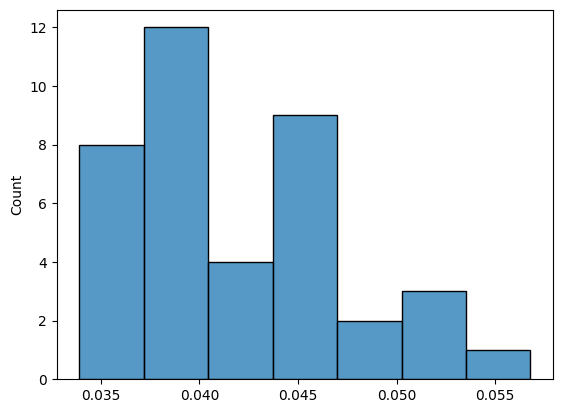

In [25]:
sns.histplot(max_corrs_per_neuron)

In [10]:
# 7. 绘制test image的每一个有反应neuron的PETH（加std）：每个neuron每个image的mean PETH和std（仅test=1的trials）
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

rec_params_test = rec_params[rec_params['test'] == 1]
test_trial_indices = rec_params_test.index.values

# 确保索引有效（使用重新计算的PETH矩阵）
n_trials_total, n_neurons_total, n_time_bins_total = trial_peth_matrix_responsive.shape
test_trial_indices = test_trial_indices[test_trial_indices < n_trials_total]

print(f"\n总trials数: {n_trials_total}")
print(f"有反应neurons数: {n_neurons_total}")
print(f"test=1的trials数: {len(test_trial_indices)}")

# 直接从重新计算的PETH矩阵中筛选test=1的trials（已经只包含有反应的neurons）
filtered_peth_matrix = trial_peth_matrix_responsive[test_trial_indices, :, :]  # (n_test_trials, n_responsive_neurons, n_time_bins_total)

n_filtered_neurons = n_responsive_neurons

unique_images = sorted(rec_params_test['image_path'].unique())
n_images = len(unique_images)
print(f"\n唯一image数量: {n_images}")

# 使用已经定义的time_bins（从Cell 9）
time_bins_center = (time_bins[:-1] + time_bins[1:]) / 2  # bin中心点

# 创建PDF文件
peth_by_image_pdf_path = os.path.join(output_dir, "peth_by_image_test_only_responsive.pdf")

with PdfPages(peth_by_image_pdf_path) as pdf:
    for image_idx, image_path in enumerate(unique_images):
        print(f"  处理image {image_idx+1}/{n_images}: {image_path}")
        
        # 获取该image的所有trials（在test=1的trials中）
        image_trial_mask = rec_params_test['image_path'] == image_path
        image_trial_indices_in_rec_params = rec_params_test[image_trial_mask].index.values
        
        # 需要找到这些索引在test_trial_indices中的位置（即filtered_peth_matrix中的位置）
        # 创建从rec_params索引到test_trial_indices位置的映射
        trial_index_map = {idx: pos for pos, idx in enumerate(test_trial_indices)}
        image_trial_positions = [trial_index_map[idx] for idx in image_trial_indices_in_rec_params if idx in trial_index_map]
        
        if len(image_trial_positions) == 0:
            print(f"    警告: image {image_path} 没有有效的trials")
            continue
        
        # 从filtered_peth_matrix中获取该image的PETH数据（已经减去了baseline）
        image_peth_data = filtered_peth_matrix[image_trial_positions, :, :]  # (n_trials_for_image, n_responsive_neurons, n_time_bins_total)
        
        # 计算mean和std
        mean_peth = np.mean(image_peth_data, axis=0)  # (n_neurons, n_time_bins_total)
        std_peth = np.std(image_peth_data, axis=0)   # (n_neurons, n_time_bins_total)
        
        # 创建图形：每个neuron一个subplot
        n_cols = 5
        n_rows = int(np.ceil(n_filtered_neurons / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
        axes = axes.flatten() if n_filtered_neurons > 1 else [axes]
        
        # 为每个neuron绘制PETH
        for neuron_idx in range(n_filtered_neurons):
            ax = axes[neuron_idx]
            
            # 绘制mean PETH
            ax.plot(time_bins_center, mean_peth[neuron_idx, :], 
                   color='black', linewidth=2, label='Mean')
            
            # # 填充std区域
            # ax.fill_between(time_bins_center, 
            #               mean_peth[neuron_idx, :] - std_peth[neuron_idx, :],
            #               mean_peth[neuron_idx, :] + std_peth[neuron_idx, :],
            #               color='lightgray', alpha=0.5, label='±1 SD')
            
            # 设置标题和标签
            neuron_id = responsive_neuron_ids_sorted[neuron_idx]
            ax.set_title(f'Neuron {neuron_id}', fontsize=10)
            ax.set_xlabel('Time (ms)', fontsize=9)
            ax.set_ylabel('Firing Rate Change (Hz)', fontsize=9)
            ax.grid(True, alpha=0.3)
            
            # 只在第一个subplot显示legend
            if neuron_idx == 0:
                ax.legend(fontsize=8)
        
        # 隐藏多余的subplot
        for idx in range(n_filtered_neurons, len(axes)):
            axes[idx].axis('off')
        
        # 设置总标题
        # 提取image文件名（去掉路径）
        image_name = image_path.split('/')[-1] if '/' in image_path else image_path
        fig.suptitle(f'Image: {image_name}\nTrials: {len(image_trial_positions)}', 
                    fontsize=14, fontweight='bold')
        
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"\n完成! PETH图已保存到: {peth_by_image_pdf_path}")
print(f"共 {n_images} 页，每页包含 {n_filtered_neurons} 个neurons的PETH")



总trials数: 10341
有反应neurons数: 39
test=1的trials数: 2776

唯一image数量: 100
  处理image 1/100: /media/ubuntu/sda/visual_stimuli_pattern/things/test/test_01.jpg
  处理image 2/100: /media/ubuntu/sda/visual_stimuli_pattern/things/test/test_02.jpg
  处理image 3/100: /media/ubuntu/sda/visual_stimuli_pattern/things/test/test_03.jpg
  处理image 4/100: /media/ubuntu/sda/visual_stimuli_pattern/things/test/test_04.jpg
  处理image 5/100: /media/ubuntu/sda/visual_stimuli_pattern/things/test/test_05.jpg
  处理image 6/100: /media/ubuntu/sda/visual_stimuli_pattern/things/test/test_06.jpg
  处理image 7/100: /media/ubuntu/sda/visual_stimuli_pattern/things/test/test_07.jpg
  处理image 8/100: /media/ubuntu/sda/visual_stimuli_pattern/things/test/test_08.jpg
  处理image 9/100: /media/ubuntu/sda/visual_stimuli_pattern/things/test/test_09.jpg
  处理image 10/100: /media/ubuntu/sda/visual_stimuli_pattern/things/test/test_10.jpg
  处理image 11/100: /media/ubuntu/sda/visual_stimuli_pattern/things/test/test_100.jpg
  处理image 12/100: /media/

In [ ]:
# 10. 对train trials的PETH进行非负参数分解，然后kmeans聚类，并用UMAP可视化
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from umap import UMAP
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from collections import Counter
from tensorly.decomposition import non_negative_parafac
import tensorly as tl

print("开始重新计算：非负参数分解 -> PCA -> KMeans -> UMAP...")

# 重新筛选train trials
rec_params_train_recalc = rec_params[rec_params['train'] == 1].copy()
train_trial_indices_all = rec_params_train_recalc.index.values

# 确保索引有效（基于trial_peth_matrix_responsive）
n_trials_total, n_neurons_total, n_time_bins_total = trial_peth_matrix_responsive.shape
train_trial_indices_valid = train_trial_indices_all[train_trial_indices_all < n_trials_total]

print(f"Train trials数量: {len(train_trial_indices_valid)}")
print(f"Responsive neurons数量: {n_neurons_total}")

# 提取train trials的PETH数据
train_peth_matrix_recalc = trial_peth_matrix_responsive[train_trial_indices_valid, :, :]
print(f"Train PETH矩阵形状: {train_peth_matrix_recalc.shape} (n_trials x n_neurons x n_time_bins)")

# 截取有反应的部分：bin 25-76（索引25:76，共51个bin）
response_window_start = 25
response_window_end = 76
train_peth_response_window = train_peth_matrix_recalc[:, :, response_window_start:response_window_end]
print(f"截取的响应窗口PETH形状: {train_peth_response_window.shape} (n_trials x n_neurons x 51时间bins)")

# 确保数据为非负（整体偏移）
min_value = np.min(train_peth_response_window)
if min_value < 0:
    print(f"检测到负值，最小值为: {min_value:.4f}")
    epsilon = 1e-6
    offset = -min_value + epsilon
    train_peth_response_window = train_peth_response_window + offset
    print(f"应用偏移量 {offset:.4f}，使得所有值为非负")
else:
    print(f"数据已为非负，范围: [{min_value:.4f}, {np.max(train_peth_response_window):.4f}]")
    offset = 0.0

# 进行非负参数分解
rank = 60
print(f"\n开始非负参数分解，rank={rank}...")
factors = non_negative_parafac(
    train_peth_response_window,
    rank=rank,
    init='random',
    n_iter_max=500,
    tol=1e-6
)
print("非负参数分解完成！")

# 提取trial embedding并缩放
trial_embedding = factors.factors[0]  # (n_trials, rank)
norms = [tl.norm(f, 2) for f in factors.factors]
lambda_vec = factors.weights * np.prod(norms, axis=0)
trial_embedding_scaled = trial_embedding * lambda_vec
print(f"Trial embedding (缩放后)形状: {trial_embedding_scaled.shape}")

# 进行PCA降维
print(f"\n进行PCA降维...")
pca = PCA(n_components=min(20, rank, trial_embedding_scaled.shape[0]-1))
trial_embedding_pca = pca.fit_transform(trial_embedding_scaled)
print(f"PCA后形状: {trial_embedding_pca.shape}")
print(f"解释方差比 (前5个): {pca.explained_variance_ratio_[:5]}")

print(f"\nTrial embedding PCA形状: {trial_embedding_pca.shape}")

# 获取train trials的image信息（使用之前筛选的train_trial_indices_valid）
train_image_paths_full = rec_params_train_recalc.loc[train_trial_indices_valid, 'image_path'].values

# 确保长度匹配
n_trials_available = trial_embedding_pca.shape[0]
if len(train_image_paths_full) != n_trials_available:
    print(f"警告: image_paths长度 ({len(train_image_paths_full)}) 与embedding长度 ({n_trials_available}) 不匹配，进行截断")
    train_image_paths_full = train_image_paths_full[:n_trials_available]

print(f"\nTrain trials数量: {len(train_image_paths_full)} (匹配embedding长度: {n_trials_available})")

# 从image_path中提取class（倒数第二层目录名）
def extract_class_from_path(image_path):
    """从完整路径中提取class，例如：/a/b/photo_booth/photo_booth_10s.jpg -> photo_booth"""
    path_str = str(image_path)
    parts = path_str.replace('\\', '/').strip('/').split('/')
    if len(parts) >= 2:
        # 返回倒数第二层目录名
        return parts[-2]
    return path_str.split('/')[-1].split('_')[0]  # 如果只有一层，尝试从文件名提取

train_classes = [extract_class_from_path(p) for p in train_image_paths_full]
unique_classes = sorted(np.unique(train_classes))
print(f"唯一class数量: {len(unique_classes)}")

# 对PCA结果进行kmeans聚类
print(f"\n进行kmeans聚类...")
n_clusters = 2  # 可以根据需要调整
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(trial_embedding_pca)

# 进行UMAP降维到2D
print(f"\n进行UMAP降维到2D...")
umap_reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
trial_embedding_umap = umap_reducer.fit_transform(trial_embedding_pca)

print(f"UMAP降维完成，形状: {trial_embedding_umap.shape}")

print(f"\n统计各个cluster的class分布...")
cluster_class_stats = {}
for cluster_id in range(n_clusters):
    cluster_mask = cluster_labels == cluster_id
    cluster_trials = np.sum(cluster_mask)
    cluster_classes = [train_classes[i] for i in np.where(cluster_mask)[0]]
    class_counts = Counter(cluster_classes)
    
    cluster_class_stats[cluster_id] = {
        'n_trials': cluster_trials,
        'classes': dict(class_counts),
        'unique_classes': sorted(class_counts.keys())
    }

# 绘制UMAP scatter plot，颜色用kmeans结果标记
print(f"\n绘制UMAP scatter plot...")
fig, ax = plt.subplots(figsize=(12, 10))

# 为每个cluster分配颜色
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

# 绘制每个cluster的点
for cluster_id in range(n_clusters):
    cluster_mask = cluster_labels == cluster_id
    ax.scatter(
        trial_embedding_umap[cluster_mask, 0],
        trial_embedding_umap[cluster_mask, 1],
        c=[colors[cluster_id]],
        label=f'Cluster {cluster_id} (n={np.sum(cluster_mask)})',
        alpha=0.6,
        s=20
    )

ax.set_xlabel('UMAP Dimension 1', fontsize=12)
ax.set_ylabel('UMAP Dimension 2', fontsize=12)
ax.set_title(f'UMAP Visualization of Trial Embeddings (colored by KMeans, k={n_clusters})', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

umap_plot_path = os.path.join(output_dir, "trial_embedding_umap_kmeans.pdf")
plt.savefig(umap_plot_path, bbox_inches='tight', dpi=150)
plt.close()
print(f"UMAP scatter plot已保存到: {umap_plot_path}")

# 保存结果
np.save(os.path.join(output_dir, "kmeans_cluster_labels.npy"), cluster_labels)
np.save(os.path.join(output_dir, "trial_embedding_umap_2d.npy"), trial_embedding_umap)

cluster_class_df = []
for cluster_id, stats in cluster_class_stats.items():
    for class_name, count in stats['classes'].items():
        cluster_class_df.append({
            'cluster_id': cluster_id,
            'class': class_name,
            'n_trials': count,
            'n_unique_classes_in_cluster': len(stats['unique_classes']),
            'total_trials_in_cluster': stats['n_trials']
        })

cluster_class_stats_df = pd.DataFrame(cluster_class_df)
cluster_class_stats_df = cluster_class_stats_df.sort_values(['cluster_id', 'n_trials'], ascending=[True, False])
cluster_class_stats_csv_path = os.path.join(output_dir, "kmeans_cluster_class_statistics.csv")
cluster_class_stats_df.to_csv(cluster_class_stats_csv_path, index=False)
print(f"\nCluster-class统计信息已保存到: {cluster_class_stats_csv_path}")




开始重新计算：非负参数分解 -> PCA -> KMeans -> UMAP...
Train trials数量: 7565
Responsive neurons数量: 39
Train PETH矩阵形状: (7565, 39, 99) (n_trials x n_neurons x n_time_bins)
截取的响应窗口PETH形状: (7565, 39, 51) (n_trials x n_neurons x 51时间bins)
检测到负值，最小值为: -215.0131
应用偏移量 215.0131，使得所有值为非负

开始非负参数分解，rank=60...
非负参数分解完成！
Trial embedding (缩放后)形状: (7565, 60)

进行PCA降维...
PCA后形状: (7565, 20)
解释方差比 (前5个): [0.05641737 0.04589536 0.04017663 0.03806348 0.0362326 ]

Trial embedding PCA形状: (7565, 20)

Train trials数量: 7565 (匹配embedding长度: 7565)
唯一class数量: 1842

进行kmeans聚类...

进行UMAP降维到2D...
UMAP降维完成，形状: (7565, 2)

统计各个cluster的class分布...

绘制UMAP scatter plot...
UMAP scatter plot已保存到: /home/ubuntu/Documents/jct/project/sorted/251205_kilosort/trial_embedding_umap_kmeans.pdf


In [48]:
# 保存反应矩阵和对应的trial image信息
print(f"\n保存反应矩阵和trial image信息...")
response_matrix = train_peth_matrix_recalc[:, :, response_window_start:response_window_end]
print(f"反应矩阵形状: {response_matrix.shape} (n_trials x n_neurons x 51时间bins)")

# 获取对应的trial image信息
trial_image_info = rec_params_train_recalc.loc[train_trial_indices_valid, ['image_path']].copy()
trial_image_info = trial_image_info.reset_index(drop=True)

# 确保长度匹配
if len(trial_image_info) != response_matrix.shape[0]:
    print(f"警告: image信息长度 ({len(trial_image_info)}) 与反应矩阵长度 ({response_matrix.shape[0]}) 不匹配，进行截断")
    trial_image_info = trial_image_info.iloc[:response_matrix.shape[0]].copy()

response_matrix_path = os.path.join(output_dir, "response_matrix_train.npy")
np.save(response_matrix_path, response_matrix.astype(np.float32))
print(f"反应矩阵已保存到: {response_matrix_path}")
print(f"  形状: {response_matrix.shape} (n_trials={response_matrix.shape[0]}, n_neurons={response_matrix.shape[1]}, n_time_bins={response_matrix.shape[2]})")

trial_image_info_path = os.path.join(output_dir, "trial_image_info_train.csv")
trial_image_info.to_csv(trial_image_info_path, index=False)
print(f"Trial image信息已保存到: {trial_image_info_path}")
print(f"  包含 {len(trial_image_info)} 个trials")
print(f"  列: {trial_image_info.columns.tolist()}")



保存反应矩阵和trial image信息...
反应矩阵形状: (7565, 39, 51) (n_trials x n_neurons x 51时间bins)
反应矩阵已保存到: /home/ubuntu/Documents/jct/project/sorted/251205_kilosort/response_matrix_train.npy
  形状: (7565, 39, 51) (n_trials=7565, n_neurons=39, n_time_bins=51)
Trial image信息已保存到: /home/ubuntu/Documents/jct/project/sorted/251205_kilosort/trial_image_info_train.csv
  包含 7565 个trials
  列: ['image_path']


In [116]:
a = np.load("/home/ubuntu/Desktop/psth_matrix.npy")

In [ ]:
b = np.load("/home/ubuntu/Desktop/trial_image_id.pkl")

In [10]:
import pickle
with open("/media/ubuntu/sda/neuropixels/natural_image/activity_dict_30000.pkl", 'rb') as f:
    b = pickle.load(f)


In [11]:
b.keys()

dict_keys(['950993090_session_743475441', '950993108_session_743475441', '950993123_session_743475441', '950993198_session_743475441', '950993250_session_743475441', '950993309_session_743475441', '950993315_session_743475441', '950993413_session_743475441', '950993660_session_743475441', '950996253_session_743475441', '950996509_session_743475441', '950996765_session_743475441', '950996806_session_743475441', '950996848_session_743475441', '950997242_session_743475441', '951001949_session_743475441', '951002099_session_743475441', '951002207_session_743475441', '951002233_session_743475441', '951002436_session_743475441', '951002426_session_743475441', '951002514_session_743475441', '951002502_session_743475441', '951002854_session_743475441', '951002781_session_743475441', '951006813_session_743475441', '951006841_session_743475441', '951006827_session_743475441', '951006880_session_743475441', '951006949_session_743475441', '951007370_session_743475441', '951011021_session_743475441

In [12]:
b['VISp'].shape

KeyError: 'VISp'

In [126]:
c = a[np.where(b == '5')[0], :, :]

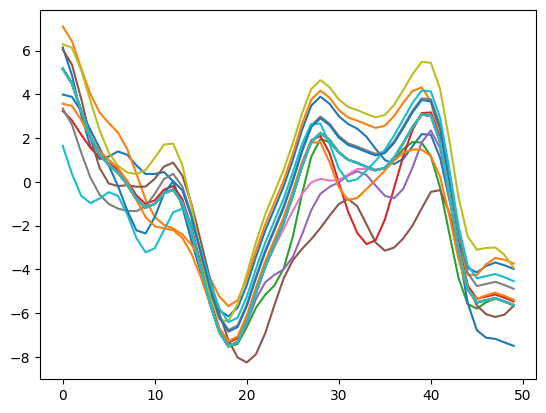

In [127]:
for i in range(20):
    sns.lineplot(c[i, :, 7])

<Axes: >

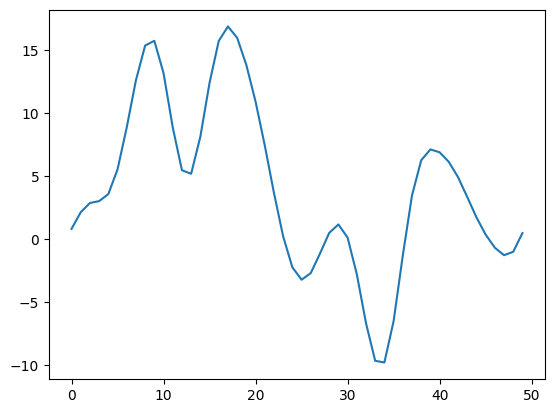

In [119]:
sns.lineplot(c.mean(axis = 0)[:, 16])

In [81]:
np.where(b == '1')

(array([ 243,  257,  292,  300,  329,  354,  496,  840, 1060, 1243, 1491,
        1533, 1649, 1813, 2041, 2047, 2132, 2135, 2290, 2359]),)

In [79]:
b.shape

AttributeError: 'list' object has no attribute 'shape'

In [50]:
a.shape

(2360, 40, 45)